In [8]:
import subprocess
import csv
from io import StringIO

# Configuration
repeats = 1
r_values = list(range(1, 2000, 30))  # R from 1 to 1400, sampling every 25 to reduce runtime

# Storage for results
results = {
    'R': [],
    'Repeats': [],
    'Time': [],
    'GFLOPs': [],
    'Bandwidth_GBs': [],
    'AI': []
}

# Run ai_bench with varying R values
for r in r_values:
    cmd = ['./ai_bench', str(r), str(repeats)]
    try:
        output = subprocess.run(cmd, capture_output=True, text=True, check=True)
        
        # Parse CSV output (last line is the data)
        lines = output.stdout.strip().split('\n')
        if lines:
            # Skip header if present and get last data line
            data_line = lines[-1] if lines[-1][0].isdigit() else lines[-2]
            
            # Parse CSV
            reader = csv.reader(StringIO(data_line))
            row = next(reader)
            
            if len(row) >= 6:
                results['R'].append(int(row[0]))
                results['Repeats'].append(int(row[1]))
                results['Time'].append(float(row[2]))
                results['GFLOPs'].append(float(row[3]))
                results['Bandwidth_GBs'].append(float(row[4]))
                results['AI'].append(float(row[5]))
                
                print(f"R={r}: AI={float(row[5]):.2f}")
    except Exception as e:
        print(f"Error running ai_bench with R={r}: {e}")

print(f"\nCollected {len(results['R'])} data points")
print(f"AI range: {min(results['AI']):.2f} to {max(results['AI']):.2f}")

R=1: AI=0.25
R=31: AI=7.75
R=61: AI=15.25
R=91: AI=22.75
R=121: AI=30.25
R=151: AI=37.75
R=181: AI=45.25
R=211: AI=52.75
R=241: AI=60.25
R=271: AI=67.75
R=301: AI=75.25
R=331: AI=82.75
R=361: AI=90.25
R=391: AI=97.75
R=421: AI=105.25
R=451: AI=112.75
R=481: AI=120.25
R=511: AI=127.75
R=541: AI=135.25
R=571: AI=142.75
R=601: AI=150.25
R=631: AI=157.75
R=661: AI=165.25
R=691: AI=172.75
R=721: AI=180.25
R=751: AI=187.75
R=781: AI=195.25
R=811: AI=202.75
R=841: AI=210.25
R=871: AI=217.75
R=901: AI=225.25
R=931: AI=232.75
R=961: AI=240.25
R=991: AI=247.75
R=1021: AI=255.25
R=1051: AI=262.75
R=1081: AI=270.25
R=1111: AI=277.75
R=1141: AI=285.25
R=1171: AI=292.75
R=1201: AI=300.25
R=1231: AI=307.75
R=1261: AI=315.25
R=1291: AI=322.75
R=1321: AI=330.25
R=1351: AI=337.75
R=1381: AI=345.25
R=1411: AI=352.75
R=1441: AI=360.25
R=1471: AI=367.75
R=1501: AI=375.25
R=1531: AI=382.75
R=1561: AI=390.25
R=1591: AI=397.75
R=1621: AI=405.25
R=1651: AI=412.75
R=1681: AI=420.25
R=1711: AI=427.75
R=1741: AI=

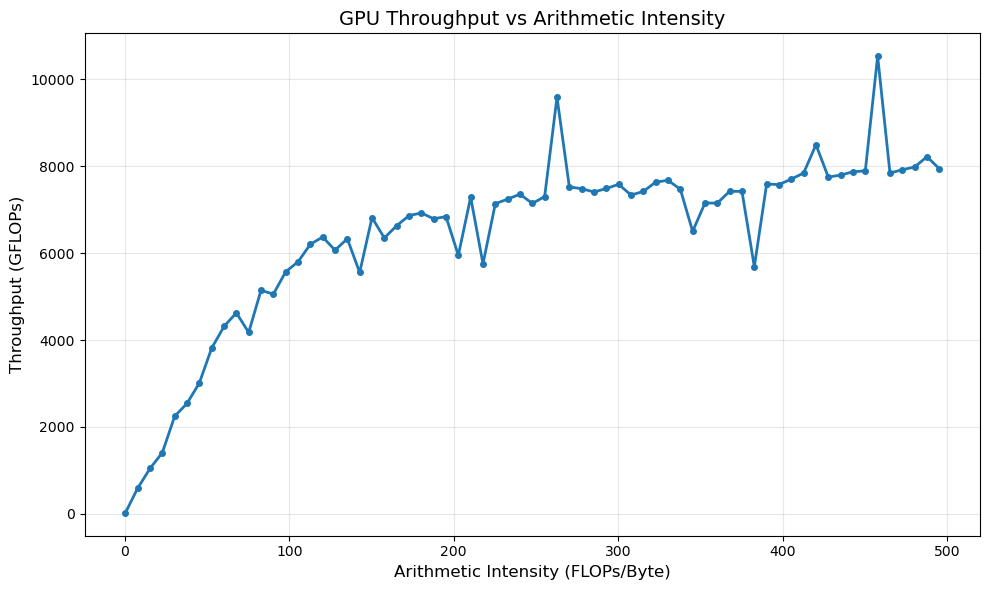

In [9]:
import matplotlib.pyplot as plt

# Create throughput vs AI plot
plt.figure(figsize=(10, 6))
plt.plot(results['AI'], results['GFLOPs'], marker='o', linewidth=2, markersize=4)
plt.xlabel('Arithmetic Intensity (FLOPs/Byte)', fontsize=12)
plt.ylabel('Throughput (GFLOPs)', fontsize=12)
plt.title('GPU Throughput vs Arithmetic Intensity', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()